# Off target MFE plot for ASOs  
MFE by RNAhybrid, using method from https://academic.oup.com/nar/article/48/2/802/5658446?utm_source=chatgpt.com&login=true

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl
from matplotlib import font_manager

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'

In [2]:
df_path = "/media/scratch/fy2306/projects/base_editing/data/ASO_rnaseq/ASO_offtarget/RNAhybrid.txt.gz"
df = pd.read_csv(df_path, sep="\t", compression="gzip", header=None)
df = df.iloc[:, [0]]
df = df[df.columns[0]].str.split(":", expand=True)
print(len(df))
df.head()

8620020


,0,1,2,3,4,5,6,7,8,9,10
0,ENST00000832824.1_exon_0_200_chr1_11121_f(+),491,723,20,-25.4,0.169520,126,G CGGC G G,UCGCA GCC GGCUGGG,AGUGU UGG CCGACUC,AA AGA
1,ENST00000832824.1_exon_1_200_chr1_12010_f(+),618,723,20,-26.7,0.123398,435,C CU U A,UCAU CCUUGGCUG G,AGUG GGAACCGAC C,UU U AGA
2,ENST00000832824.1_exon_2_200_chr1_12613_f(+),509,723,20,-26.3,0.114563,114,G AAGAG A,CACAGCC GGCUGA,GUGUUGG CCGACU,A AA CAGA
3,ENST00000832824.1_exon_3_200_chr1_13453_f(+),1360,723,20,-25.4,0.509668,756,C C A,CACAGCCUUG CUGG,GUGUUGGAAC GACU,A C CAGA
4,ENST00000832825.1_exon_0_200_chr1_11125_f(+),487,723,20,-25.4,0.167678,122,G CGGC G G,UCGCA GCC GGCUGGG,AGUGU UGG CCGACUC,AA AGA


In [3]:
df = df.drop(df.columns[[6, 7, 8, 9, 10]], axis=1)
df.columns = ["exon", "exon_len", "ASO", "ASO_len", "mfe", "pval"]
df["ASO"] = df["ASO"].astype(str)
df["mfe"] = df["mfe"].astype(float)
print(df["ASO"].unique())

['723' 'None' '723-3' '723-4' '723-5']


In [4]:
df[df["ASO"]=='None']

,exon,exon_len,ASO,ASO_len,mfe,pval
1719,target too long,ENST00000831573.1_exon_2_200_chr1_16442_r(-),None,None,NaN,None
2004,target too long,ENST00000831651.1_exon_1_200_chr1_16447_r(-),None,None,NaN,None
2143,target too long,ENST00000641515.2_exon_2_200_chr1_69037_f(+),None,None,NaN,None
2144,target too long,ENST00000466430.5_exon_3_200_chr1_89295_r(-),None,None,NaN,None
2272,target too long,ENST00000442987.3_exon_0_200_chr1_131025_f(+),None,None,NaN,None
...,...,...,...,...,...,...
8619429,target too long,ENST00000664402.3_exon_5_200_chr22_50730721_f(+),None,None,NaN,None
8619591,target too long,ENST00000395590.5_exon_5_200_chr22_50771210_r(-),None,None,NaN,None
8619626,target too long,ENST00000693416.3_exon_3_200_chr22_50788895_f(+),None,None,NaN,None
8619629,target too long,ENST00000689105.2_exon_2_200_chr22_50788750_f(+),None,None,NaN,None


In [13]:
dict_aso_name = {
    "723": "ASO-1",
    "723-3": "ASO-2",
    "723-4": "ASO-3",
    "723-5": "ASO-4",
}

def plot_lowest_mfe(df, aso_name):

    subset = df[df["ASO"] == aso_name].copy()
    subset['exon_id'] = subset['exon'].str.split('_').str[-3:].str.join('_')
    subset = subset.drop_duplicates(subset=['exon_id'])
    
    subset = subset.sort_values("mfe", ascending=True)
    subset = subset.head(1000)
    subset["rank"] = range(1, len(subset) + 1)
    
    aso_name_corrected = dict_aso_name.get(aso_name)
    print(subset.head(10))
    
    plt.figure(figsize=(4,3))
    plt.scatter(subset["rank"], subset["mfe"], s=1)
    plt.xlabel("Top 1000 targets", fontsize=13)
    plt.ylabel("MFE (kcal/mol)", fontsize=13)
    plt.title(aso_name_corrected, fontsize=14)
    plt.tick_params(axis='both', which='major', labelsize=12)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

                                                      exon exon_len  ASO  \
997372    ENST00000651626.1_exon_2_200_chr8_127740396_f(+)     1438  723   
1847243   ENST00000637943.1_exon_2_200_chr17_47914726_f(+)      536  723   
367485   ENST00000649096.1_exon_45_200_chr2_240718050_r(-)      519  723   
1668580  ENST00000299705.10_exon_2_200_chr15_79321978_f(+)     1262  723   
1904890   ENST00000731323.1_exon_0_200_chr18_22542521_f(+)      609  723   
1479652  ENST00000545182.6_exon_8_200_chr12_113386937_f(+)      553  723   
920933   ENST00000378052.5_exon_10_200_chr7_149293751_f(+)      666  723   
920932    ENST00000378052.5_exon_9_200_chr7_149293377_f(+)      516  723   
1028889    ENST00000378407.7_exon_4_200_chr9_35660774_f(+)      813  723   
1028879    ENST00000378409.7_exon_5_200_chr9_35660940_f(+)      960  723   

        ASO_len   mfe      pval               exon_id  rank  
997372       20 -42.5  0.000226   chr8_127740396_f(+)     1  
1847243      20 -38.0  0.000281   chr17

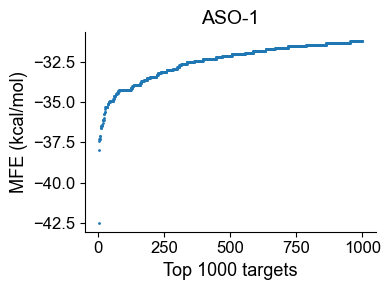

                                                     exon exon_len    ASO  \
3152377  ENST00000651626.1_exon_2_200_chr8_127740396_f(+)     1438  723-3   
2325065  ENST00000780025.1_exon_0_200_chr1_203289758_f(+)     1083  723-3   
2434591  ENST00000732831.1_exon_0_200_chr2_109700485_f(+)      806  723-3   
2434594  ENST00000732828.1_exon_0_200_chr2_109700597_f(+)      694  723-3   
2434566  ENST00000732829.1_exon_2_200_chr2_109701102_f(+)      529  723-3   
3705809  ENST00000604306.1_exon_1_200_chr14_24231652_r(-)      616  723-3   
2551872   ENST00000352511.5_exon_7_200_chr3_38481351_f(+)      515  723-3   
2890409   ENST00000753352.1_exon_0_200_chr6_32893899_r(-)     1137  723-3   
2371303   ENST00000762414.1_exon_0_200_chr2_21044155_f(+)      512  723-3   
2371305   ENST00000762415.1_exon_0_200_chr2_21044181_f(+)      486  723-3   

        ASO_len   mfe      pval              exon_id  rank  
3152377      20 -43.1  0.000165  chr8_127740396_f(+)     1  
2325065      20 -38.6  0.00083

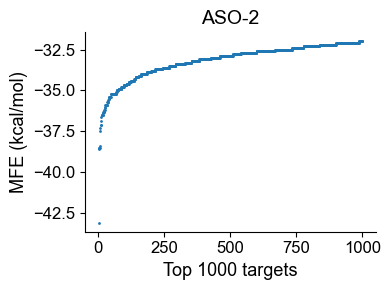

                                                      exon exon_len    ASO  \
5307382   ENST00000651626.1_exon_2_200_chr8_127740396_f(+)     1438  723-4   
6157253   ENST00000637943.1_exon_2_200_chr17_47914726_f(+)      536  723-4   
4589596   ENST00000732831.1_exon_0_200_chr2_109700485_f(+)      806  723-4   
4589599   ENST00000732828.1_exon_0_200_chr2_109700597_f(+)      694  723-4   
4589571   ENST00000732829.1_exon_2_200_chr2_109701102_f(+)      529  723-4   
6390122   ENST00000684052.1_exon_0_200_chr20_64107364_r(-)      602  723-4   
5045414    ENST00000753352.1_exon_0_200_chr6_32893899_r(-)     1137  723-4   
5860814   ENST00000604306.1_exon_1_200_chr14_24231652_r(-)      616  723-4   
5789662  ENST00000545182.6_exon_8_200_chr12_113386937_f(+)      553  723-4   
5002142   ENST00000520181.5_exon_5_200_chr5_169875226_f(+)     1051  723-4   

        ASO_len   mfe      pval               exon_id  rank  
5307382      20 -43.8  0.000143   chr8_127740396_f(+)     1  
6157253      20 -

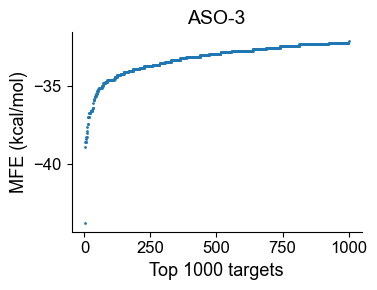

                                                     exon exon_len    ASO  \
7462387  ENST00000651626.1_exon_2_200_chr8_127740396_f(+)     1438  723-5   
7043609  ENST00000507826.2_exon_3_200_chr4_142889858_r(-)      519  723-5   
8004523  ENST00000819518.1_exon_0_200_chr14_18589944_f(+)      514  723-5   
8575022  ENST00000775242.1_exon_0_200_chr22_15517034_f(+)      522  723-5   
8575020  ENST00000775241.1_exon_0_200_chr22_15517029_f(+)      486  723-5   
8575017  ENST00000775238.1_exon_0_200_chr22_15516999_f(+)      516  723-5   
7630072  ENST00000786829.1_exon_0_200_chrX_137564331_r(-)      555  723-5   
6637854  ENST00000468057.5_exon_4_200_chr1_205798669_r(-)      547  723-5   
6688132   ENST00000731563.1_exon_1_200_chr2_28349373_r(-)      610  723-5   
6688134   ENST00000731564.1_exon_1_200_chr2_28349051_r(-)      932  723-5   

        ASO_len   mfe      pval              exon_id  rank  
7462387      19 -42.2  0.000172  chr8_127740396_f(+)     1  
7043609      19 -38.9  0.00010

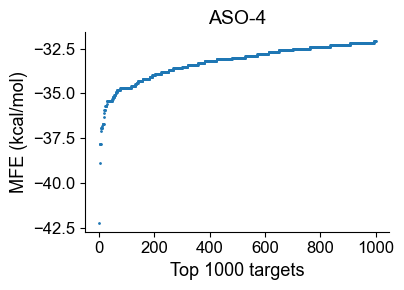

In [14]:
plot_lowest_mfe(df, "723")
plot_lowest_mfe(df, "723-3")
plot_lowest_mfe(df, "723-4")
plot_lowest_mfe(df, "723-5")